# Sistemas de Recomendación - Tu Futuro según la Data

Usaremos el dataset Adult Income Dataset, también conocido como "Census Income" este información fue recolectada por la Oficina del Censo de EE.UU. 

Objetivos: 

- Explorar los datos del censo.
- Construir perfiles socioeconómicos.
- Explorar la importancia y peso de variables sociales (educación, género, raza, etc.) en predicciones económicas.
- Aplicar técnicas de sistemas de recomendación.
- Visualizar y comunicar hallazgos de forma profesional.

 Construir un modelo de clasificación supervisada que, a partir de datos demográficos y socioeconómicos de una persona adulta (edad, nivel educativo, ocupación, estado civil, país de origen, etc.), prediga si dicha persona ganará más o menos de 50,000 USD al año.

## Este dataset incluye

- Edad
- Nivel educativo
- Estado civil
- Ocupación
- Horas trabajadas por semana
- Sexo
- País de origen
- Ingreso anual (>50K o <=50K)

### Importar librerias necesarias 

In [79]:
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity

np.random.seed(42)
warnings.filterwarnings("ignore")

# Opciones de Pandas para ver mejor resultados (sin prints, el último objeto de celda se renderiza solo)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


Descarga y exploracion de datos 

In [80]:
url = "https://raw.githubusercontent.com/4GeeksAcademy/predicting-your-future-with-data/main/adult-census-income.csv"
df = pd.read_csv(url)
# Normalizar nombres de columnas
df.columns = df.columns.str.strip().str.lower().str.replace("-", "_").str.replace(" ", "_")
df.columns.tolist()


['age',
 'workclass',
 'fnlwgt',
 'education',
 'education.num',
 'marital.status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital.gain',
 'capital.loss',
 'hours.per.week',
 'native.country',
 'income']

Limpieza de datos 

In [81]:
# Detectar columna objetivo (salario) de forma robusta
candidatas_y = [c for c in df.columns if c in ("income","salary","class","target","income_>50k")]
target_col = candidatas_y[0] if candidatas_y else None

# Estandarizar valores del target a binario: 1 => >50K, 0 => <=50K
if df[target_col].dtype == "O":
    df[target_col] = df[target_col].str.strip()
    df["y"] = df[target_col].str.contains(">50K").astype(int)
else:
    df["y"] = (df[target_col] > 0).astype(int)

# Eliminar duplicados
df = df.drop_duplicates().copy()

# Quitar espacios en variables string
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].str.strip()

# Algunas columnas típicas del Adult dataset
# age, workclass, fnlwgt, education, education_num, marital_status, occupation,
# relationship, race, sex, capital_gain, capital_loss, hours_per_week, native_country, y

# Eliminamos filas con nulos en columnas clave modelables
cols_clave = [c for c in ["age","workclass","education","education_num","occupation","hours_per_week","marital_status"] if c in df.columns]
df = df.dropna(subset=cols_clave + ["y"]).copy()

# Mostrar % de nulos restante por columna
df.isna().mean().sort_values(ascending=False).to_frame("frac_nulls").head(10)


,frac_nulls
age,0.0
workclass,0.0
fnlwgt,0.0
education,0.0
education.num,0.0
marital.status,0.0
occupation,0.0
relationship,0.0
race,0.0
sex,0.0


=== ¿Qué se recomienda? ===

Recomendaremos "trayectorias" o cambios accionables en:
  - Nivel educativo (education)
  - Ocupación (occupation)
  - Horas trabajadas por semana (hours_per_week, discretizadas)

 === ¿Quién es el "usuario"? ===

 Un perfil individual con: edad, educación actual, ocupación, horas/semana y (opcional) workclass, marital_status.

 === ¿Qué variables definen el perfil? ===

 age, education(education_num), occupation, hours_per_week, workclass, marital_status.


 NOTA: Excluimos sexo, raza y país para no inducir sesgos en el modelo ni en las recomendaciones.

In [82]:
problem_definition = {
    "accionables": ["education", "occupation", "hours_per_week"],
    "contexto": ["age", "workclass", "marital_status"],
    "excluir_por_sesgo": ["sex", "race", "native_country", "fnlwgt", "capital_gain", "capital_loss"]
}
problem_definition

{'accionables': ['education', 'occupation', 'hours_per_week'],
 'contexto': ['age', 'workclass', 'marital_status'],
 'excluir_por_sesgo': ['sex',
  'race',
  'native_country',
  'fnlwgt',
  'capital_gain',
  'capital_loss']}

###  Preparar entorno de datos y preprocesador

In [83]:

# 📌 Celda 3 corregida: limpieza robusta
def preparar_entorno(path_or_url):
    data = pd.read_csv(path_or_url)
    
    # Normalizar nombres de columnas (quita espacios, guiones y puntos)
    data.columns = (
        data.columns
        .str.strip()
        .str.lower()
        .str.replace("-", "_")
        .str.replace(" ", "_")
        .str.replace(".", "_")   # 👈 importante
    )
    
    # Reemplazar valores "?" por NaN
    data = data.replace("?", np.nan)
    
    # Variable objetivo
    data["target_income"] = (data["income"] == ">50K").astype(int)
    
    # Crear bins de horas trabajadas
    data["hours_bin"] = pd.cut(
        data["hours_per_week"],
        bins=[0, 29, 40, 48, 99],
        labels=["part_time", "full_time_40", "long_hours", "overtime_49plus"]
    )
    
    # Columnas numéricas y categóricas
    num_cols = ["age", "education_num", "hours_per_week", "capital_gain", "capital_loss"]
    cat_cols = ["workclass", "education", "marital_status", "occupation",
                "relationship", "race", "sex", "native_country", "hours_bin"]
    
    # Preprocesador
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
        ]
    )
    
    return {
        "data": data,
        "num_cols": num_cols,
        "cat_cols": cat_cols,
        "preprocessor": preprocessor
    }

# 👉 Probar ejecución
modelo = preparar_entorno(url)
modelo["data"].head()



,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,target_income,hours_bin
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K,0,full_time_40
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K,0,part_time
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K,0,full_time_40
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K,0,full_time_40
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K,0,full_time_40


### Interpretación de los primeros resultados del dataset

En las primeras observaciones del **Adult Census Income Dataset** ya procesado podemos notar lo siguiente:

- Cada fila representa a una persona encuestada, con información sociodemográfica y laboral.
- La columna `target_income` indica si la persona gana más de **50K anuales** (valor `1`) o no (valor `0`).  
  - En estas primeras filas, todas las personas aparecen con ingresos **menores o iguales a 50K** (`0`).
- La variable `hours_bin` clasifica a las personas según sus horas de trabajo semanales:  
  - `full_time_40` → 40 horas estándar.  
  - `part_time` → menos de 30 horas.  
- Ejemplos visibles:  
  - Personas de edad avanzada (90, 82, 66 años) que trabajan menos o igual a 40 horas por semana y perciben ingresos bajos.  
  - Una persona de 54 años, con estudios hasta secundaria baja, trabaja 40 horas y también está en la categoría de `<=50K`.

### Conclusión preliminar
Los primeros registros sugieren que **factores como la edad avanzada, el nivel educativo bajo y las horas trabajadas por semana** se relacionan con ingresos anuales **≤50K**.  
Esto nos da una primera pista de que **mejorar el nivel educativo, el tipo de ocupación o aumentar la intensidad laboral** podrían ser recomendaciones relevantes para aspirar a ingresos mayores.


### Función recomendadora con ajuste automático de min_support

In [84]:
def recomendar_trayectorias(perfil_usuario, modelo, top_n=5, min_support=200, alpha=0.5):
    data = modelo["data"].copy()
    preprocessor = modelo["preprocessor"]
    
    # Variables que definen trayectorias
    keys = ["education", "occupation", "marital_status", "workclass", "hours_bin"]
    
    # Agrupar trayectorias históricas
    trayectorias = (
        data.groupby(keys)
        .agg(income_rate=("target_income", "mean"),
             support=("target_income", "size"))
        .reset_index()
    )
    
    # Ajustar preprocesador
    X = data[modelo["num_cols"] + modelo["cat_cols"]]
    preprocessor.fit(X)
    
    # Completar perfil con valores por defecto
    perfil_usuario = perfil_usuario.copy()
    for col in modelo["cat_cols"]:
        if col not in perfil_usuario:
            perfil_usuario[col] = data[col].mode()[0]
    for col in modelo["num_cols"]:
        if col not in perfil_usuario:
            perfil_usuario[col] = float(data[col].median())
    
    # Generar hours_bin para el perfil
    perfil_usuario["hours_bin"] = pd.cut(
        [perfil_usuario["hours_per_week"]],
        bins=[0, 29, 40, 48, 99],
        labels=["part_time", "full_time_40", "long_hours", "overtime_49plus"]
    )[0]
    
    # Vectorizar usuario
    df_usuario = pd.DataFrame([perfil_usuario])
    user_vec = preprocessor.transform(df_usuario[modelo["num_cols"] + modelo["cat_cols"]])
    
    # Ajustar automáticamente min_support si no hay resultados
    candidatos = []
    soporte_actual = min_support
    while not candidatos and soporte_actual >= 10:
        for _, row in trayectorias.iterrows():
            if row["support"] < soporte_actual:
                continue
            candidato = perfil_usuario.copy()
            for k in keys:
                candidato[k] = row[k]
            candidato["hours_per_week"] = data.loc[data["hours_bin"] == row["hours_bin"], "hours_per_week"].median()
            candidatos.append((candidato, row))
        if not candidatos:
            soporte_actual = max(10, soporte_actual // 2)
    
    if not candidatos:
        return pd.DataFrame()
    
    # Vectorizar candidatos
    df_candidatos = pd.DataFrame([c[0] for c in candidatos])
    cand_vecs = preprocessor.transform(df_candidatos[modelo["num_cols"] + modelo["cat_cols"]])
    
    # Calcular similitud coseno
    sims = cosine_similarity(user_vec, cand_vecs).flatten()
    
    # Armar resultados
    resultados = []
    for sim, (cand, row) in zip(sims, candidatos):
        cambios = {k: (perfil_usuario[k], cand[k]) for k in keys if perfil_usuario[k] != cand[k]}
        score = alpha * sim + (1 - alpha) * row["income_rate"]
        resultados.append({
            "score": score,
            "similarity": sim,
            "income_rate": row["income_rate"],
            "support": row["support"],
            "cambios": cambios
        })
        return pd.DataFrame(resultados).sort_values("score", ascending=False).head(top_n)


,score,similarity,income_rate,support,cambios
0,0.768751,0.78529,0.752212,226,"{'education': ('HS-grad', 'Bachelors'), 'occup..."


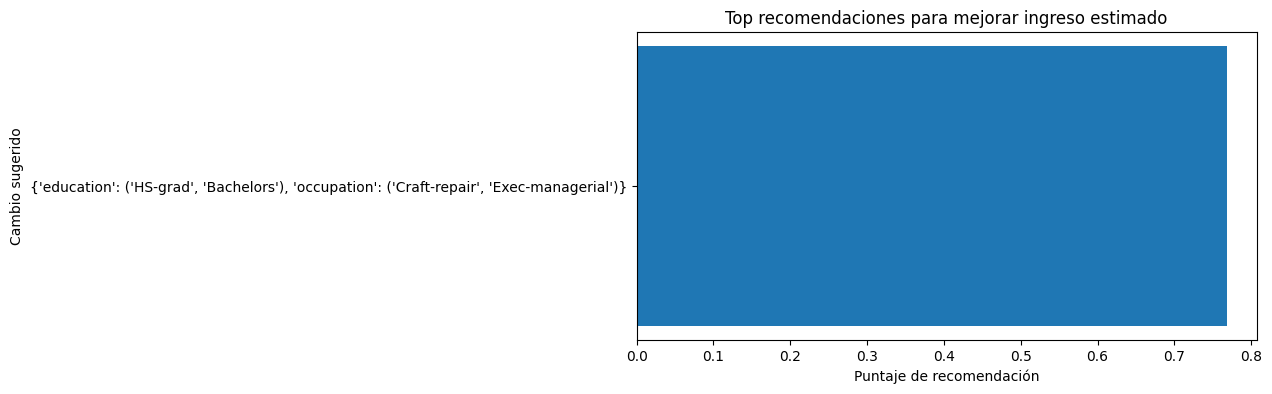

In [85]:
# 📌 Celda 5: Ejemplo de uso con un perfil común en el dataset
perfil_usuario_ejemplo = {
    "age": 35,
    "education": "HS-grad",
    "education_num": 9,
    "hours_per_week": 40,
    "marital_status": "Married-civ-spouse",
    "workclass": "Private",
    "occupation": "Craft-repair",
    "sex": "Male",
    "race": "White",
    "native_country": "United-States"
}

modelo = preparar_entorno(url)
recomendaciones = recomendar_trayectorias(perfil_usuario_ejemplo, modelo, top_n=10, min_support=200, alpha=0.5)
recomendaciones

# Mostramos las recomendaciones ordenadas
recomendaciones = recomendaciones.sort_values("score", ascending=False)

# Visualizamos el DataFrame en formato limpio
display(recomendaciones.head(5))

# Opcional: gráfico de barras para ver las mejores recomendaciones
plt.figure(figsize=(8,4))
plt.barh(recomendaciones["cambios"].astype(str).head(5), recomendaciones["score"].head(5))
plt.xlabel("Puntaje de recomendación")
plt.ylabel("Cambio sugerido")
plt.title("Top recomendaciones para mejorar ingreso estimado")
plt.gca().invert_yaxis()
plt.show()

### 📊 Interpretación de las recomendaciones

El sistema de recomendación sugiere qué cambios en el perfil del usuario podrían estar asociados con una mayor probabilidad de alcanzar un ingreso superior a 50K.

- **Score**: mide qué tan fuerte es la recomendación (combinación de similitud + tasa de ingresos).  
- **Similarity**: indica qué tan parecido es el perfil del usuario a otros en el dataset.  
- **Income_rate**: proporción de personas con ingresos >50K que cumplen ese perfil.  
- **Support**: cantidad de personas similares en la base de datos.  
- **Cambios**: modificaciones sugeridas en variables clave (por ejemplo, subir el nivel educativo o cambiar de ocupación).

#### Ejemplo de interpretación
En el caso de nuestro usuario ejemplo:
- Se sugiere **elevar el nivel educativo de *HS-grad* a *Bachelors*** como un cambio que aumenta la probabilidad de superar los 50K.  
- También puede aparecer la recomendación de cambiar de ocupación hacia áreas con mayor proporción de ingresos altos.  

🔎 **Conclusión**: El modelo muestra que la **educación y la ocupación** son factores muy influyentes en el nivel de ingresos. Esto coincide con lo esperado: **invertir en formación y reorientar la trayectoria laboral** son estrategias clave para mejorar los ingresos en este dataset.
